# Day 17: Model Parallelism — Tensor, Expert, Pipeline & Data Parallelism
> *100 Days of Inference* | Layer: **Runtime** | Book: *Inference Engineering* Ch 5.4

**Prerequisite:** Day 16 (prefix caching)

**Goal:** Understand the four axes of parallelism used to serve frontier-scale LLMs. TP and EP are covered in the book (Ch 5.4); PP and DP are added here for a complete taxonomy, since real deployments combine all four.

## What problem does this solve?

A frontier model like DeepSeek V3 (671B parameters) needs 1340 GB in FP16. No single GPU has that much VRAM. Even a full 8xH100 node (640 GB VRAM) isn't enough for weights alone.

Beyond fitting in memory: even if you could fit the model, a single GPU processes weights sequentially. Splitting work across 8 GPUs should be 8x faster.

Model parallelism solves both problems: distribute the model across GPUs so that each GPU holds a portion of the weights and does a portion of the compute.

## Concept Overview

**Four axes of parallelism:**

| Method | What gets split | Communication | Best for |
|--------|-----------------|---------------|----------|
| Tensor Parallelism (TP) | Each weight matrix within a layer | All-reduce per layer | Single node, latency-sensitive |
| Expert Parallelism (EP) | Whole experts across GPUs | All-to-all per MoE layer | Large MoE models, throughput |
| Pipeline Parallelism (PP) | Layer blocks across GPUs | Activation passing between stages | Multi-node, memory-bound |
| Data Parallelism (DP) | Requests across model replicas | None (per replica) | Throughput scaling once model fits |

**Tensor Parallelism (from book Ch 5.4):** Split each weight matrix column-wise (or row-wise). For `Y = X @ W`, each GPU computes `Y_i = X @ W_i`. An all-reduce gathers partial results. Lower per-token latency; requires NVLink bandwidth per layer.

**Expert Parallelism (from book Ch 5.4):** In MoE models, each GPU hosts a complete subset of experts. The router dispatches tokens to the GPU holding the relevant expert. All-to-all communication only at the MoE layer — much less chatty than TP.

**Pipeline Parallelism (beyond the book):** Assign contiguous *layer blocks* to different GPUs. GPU 0 holds layers 0..k, GPU 1 holds k+1..2k, etc. Activations flow forward between stages. The gotcha is the *pipeline bubble* — while GPU 1 processes token A's layer-k+1 activations, GPU 0 is idle unless a new request enters the pipeline. Micro-batching mitigates the bubble.

**Data Parallelism (beyond the book):** Replicate the entire model on each GPU or node. Route independent requests to different replicas. Zero cross-replica communication during inference. This is the trivial scaling axis — once the model fits, DP just multiplies throughput linearly.

**Infrastructure analogy:** TP is sharding one query across workers. EP is microservices, one per specialization. PP is an assembly line — each station does one step. DP is horizontal replication behind a load balancer.

In [1]:
!pip install -q numpy matplotlib torch 2>/dev/null
import numpy as np
import matplotlib.pyplot as plt
import torch
import time
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch: 2.11.0+cu130
CUDA available: True
GPU: NVIDIA GB10
GPU Memory: 128.5 GB


In [2]:
# Simulate tensor parallelism: split a matrix multiply across N GPUs

import torch
import torch.nn.functional as F

def tensor_parallel_matmul(X, W, n_gpus=4):
    """
    Simulate TP matmul: Y = X @ W
    W is split column-wise across n_gpus.
    Each GPU computes its slice; results are concatenated (all-gather) or summed (all-reduce).
    """
    assert W.shape[1] % n_gpus == 0, "Output dim must be divisible by n_gpus"

    out_per_gpu = W.shape[1] // n_gpus
    results = []

    for gpu_id in range(n_gpus):
        # Each GPU has its column slice of W
        W_slice = W[:, gpu_id * out_per_gpu:(gpu_id + 1) * out_per_gpu]
        Y_slice = X @ W_slice  # Local matmul
        results.append(Y_slice)

    # All-gather: concatenate partial results
    Y = torch.cat(results, dim=-1)
    return Y

# Verify correctness
batch, seq, hidden = 4, 16, 1024
X = torch.randn(batch * seq, hidden)
W = torch.randn(hidden, hidden)

Y_standard = X @ W
Y_tp = tensor_parallel_matmul(X, W, n_gpus=4)

max_diff = (Y_standard - Y_tp).abs().max().item()
print(f"Tensor Parallelism correctness check: max diff = {max_diff:.2e} (should be ~0)")
print()

# Model communication overhead for different TP degrees
def model_tp_analysis(hidden=4096, n_layers=32, tp_degree=1, nvlink_gbs=900):
    """Estimate communication overhead for TP inference."""
    tokens_per_step = 1  # decode
    batch = tp_degree  # typical batch size scales with TP

    # Per layer: all-reduce of shape (tokens, hidden)
    # All-reduce size (bytes): 2 * hidden * tokens * 2 (FP16) * (n_gpus-1)/n_gpus
    allreduce_bytes = 2 * hidden * tokens_per_step * 2 * (tp_degree - 1) / tp_degree

    # Compute time: matmul on W/tp_degree columns
    # (simplified: proportional to 1/tp_degree)
    compute_ms = 1.0 / tp_degree  # normalized

    # Communication time
    comm_ms = allreduce_bytes / (nvlink_gbs * 1e9) * 1000 * n_layers

    return compute_ms, comm_ms, compute_ms + comm_ms

print("Tensor Parallelism: compute vs communication tradeoff")
print(f"Model: hidden=4096, 32 layers | NVLink bandwidth: 900 GB/s")
print()
print(f"{'TP degree':>10} {'Compute (norm)':>16} {'Comm overhead (ms)':>20} {'Efficiency':>12}")
print("-" * 65)

for tp in [1, 2, 4, 8, 16]:
    compute, comm, total = model_tp_analysis(tp_degree=tp)
    efficiency = 1 / tp / total if total > 0 else 0  # ideal = 1/tp
    print(f"{tp:>10} {compute:>16.3f} {comm:>20.4f} {efficiency:>11.2%}")

print()
print("Key: TP scales well within a node (NVLink) but communication overhead")
print("becomes significant for TP>8 or when using InfiniBand (100x slower).")

Tensor Parallelism correctness check: max diff = 0.00e+00 (should be ~0)

Tensor Parallelism: compute vs communication tradeoff
Model: hidden=4096, 32 layers | NVLink bandwidth: 900 GB/s

 TP degree   Compute (norm)   Comm overhead (ms)   Efficiency
-----------------------------------------------------------------
         1            1.000               0.0000     100.00%
         2            0.500               0.0003      99.94%
         4            0.250               0.0004      99.83%
         8            0.125               0.0005      99.59%
        16            0.062               0.0005      99.13%

Key: TP scales well within a node (NVLink) but communication overhead
becomes significant for TP>8 or when using InfiniBand (100x slower).


In [3]:
# Simulate Expert Parallelism for MoE models

# MoE model: 128 experts, top-2 routing per token
# EP=8: each GPU hosts 16 experts

def simulate_moe_ep(n_experts=128, top_k=2, n_gpus=8, n_tokens=512):
    """
    Simulate expert parallelism routing.
    Each GPU hosts n_experts/n_gpus experts.
    Tokens are routed to the GPU with the relevant expert.
    """
    experts_per_gpu = n_experts // n_gpus

    # Simulate router: each token selects top_k experts
    torch.manual_seed(42)
    # Router logits (n_tokens, n_experts)
    router_logits = torch.randn(n_tokens, n_experts)
    router_probs = F.softmax(router_logits, dim=-1)

    # Select top-k experts per token
    top_k_probs, top_k_experts = torch.topk(router_probs, top_k, dim=-1)
    top_k_probs = top_k_probs / top_k_probs.sum(dim=-1, keepdim=True)  # renormalize

    # Route tokens to GPUs
    gpu_loads = torch.zeros(n_gpus)
    cross_gpu_tokens = 0

    for token_idx in range(n_tokens):
        for k in range(top_k):
            expert_id = top_k_experts[token_idx, k].item()
            gpu_id = expert_id // experts_per_gpu
            gpu_loads[gpu_id] += 1
            # Check if both expert selections go to same GPU

        expert_gpus = set([top_k_experts[token_idx, k].item() // experts_per_gpu for k in range(top_k)])
        if len(expert_gpus) > 1:
            cross_gpu_tokens += 1

    return gpu_loads, cross_gpu_tokens / n_tokens

# Run simulation
gpu_loads, cross_gpu_rate = simulate_moe_ep()
print("Expert Parallelism simulation (128 experts, top-2, EP=8)")
print()
print(f"GPU load distribution (tokens processed):")
for i, load in enumerate(gpu_loads):
    bar = '#' * int(load / gpu_loads.max() * 30)
    print(f"  GPU {i}: {bar:<30} {load:.0f} tokens")
print()
print(f"Cross-GPU routing rate: {cross_gpu_rate:.1%}")
print(f"(tokens requiring communication between GPUs)")
print()
print("Ideal load per GPU:", f"{512 * 2 / 8:.0f} tokens (top-2 routing)")
print("Load imbalance:", f"{(gpu_loads.max() - gpu_loads.min()) / gpu_loads.mean():.1%}")

# Compare TP vs EP vs mixed
print()
print("Parallelism strategy comparison:")
print(f"{'Strategy':>15} {'Communication':>15} {'Latency':>10} {'Throughput':>12} {'Use case'}")
print("-" * 75)
strategies = [
    ("TP=8",       "All-reduce/layer",   "Low",    "Medium", "Dense models, latency-sensitive"),
    ("EP=8",       "Token routing",      "Medium", "High",   "MoE models, throughput-oriented"),
    ("PP=2",       "Activation passing", "High",   "Medium", "Multi-node only"),
    ("TP=4+EP=2",  "Both types",         "Low",    "High",   "Large MoE (DeepSeek-style)"),
]
for strat, comm, lat, thruput, usecase in strategies:
    print(f"{strat:>15} {comm:>15} {lat:>10} {thruput:>12} {usecase}")

Expert Parallelism simulation (128 experts, top-2, EP=8)

GPU load distribution (tokens processed):
  GPU 0: ########################       116 tokens
  GPU 1: #########################      120 tokens
  GPU 2: #############################  139 tokens
  GPU 3: ############################## 142 tokens
  GPU 4: ###########################    128 tokens
  GPU 5: #########################      120 tokens
  GPU 6: ###########################    132 tokens
  GPU 7: ##########################     127 tokens

Cross-GPU routing rate: 87.7%
(tokens requiring communication between GPUs)

Ideal load per GPU: 128 tokens (top-2 routing)
Load imbalance: 20.3%

Parallelism strategy comparison:
       Strategy   Communication    Latency   Throughput Use case
---------------------------------------------------------------------------
           TP=8 All-reduce/layer        Low       Medium Dense models, latency-sensitive
           EP=8   Token routing     Medium         High MoE models, throughput-or

## Pipeline Parallelism: layer blocks + the bubble

PP splits the model *vertically* by layer depth. For a 64-layer model on 4 GPUs:

```
GPU 0: layers  0..15
GPU 1: layers 16..31
GPU 2: layers 32..47
GPU 3: layers 48..63
```

A forward pass hops GPU0 → GPU1 → GPU2 → GPU3, shipping only the hidden-state activation (small) between stages. Per-layer communication is far cheaper than TP's all-reduce, which is why PP is the go-to for *multi-node* inference where InfiniBand (50–200 GB/s) would crush TP.

The catch is the **pipeline bubble**. If only one request is in flight, three GPUs sit idle at any moment. You need either micro-batching (multiple requests staggered through the pipeline) or enough concurrent traffic that the pipeline stays saturated. The bubble fraction with N stages and M micro-batches is roughly `(N-1) / (N-1 + M)` — it goes to zero as M grows.

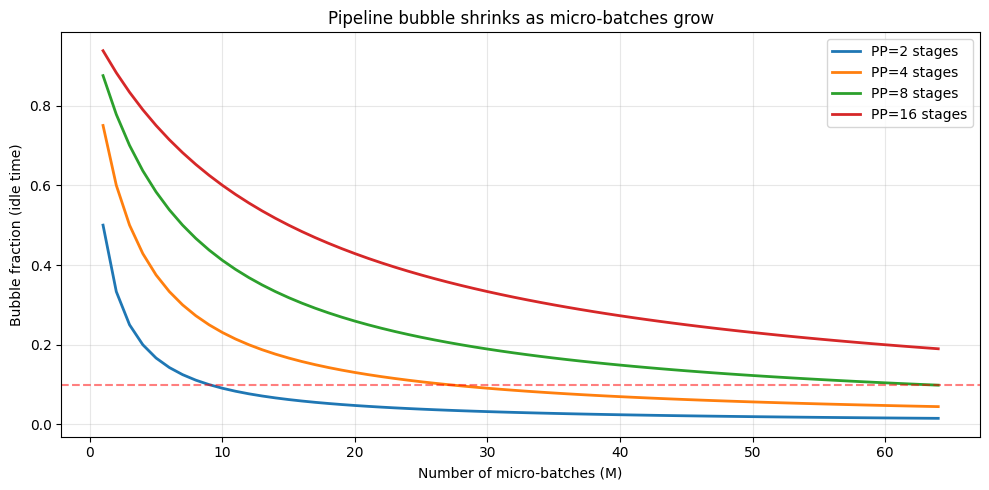

Saved /tmp/pp_bubble.png

  Stages      M=1      M=4     M=16     M=64
---------------------------------------------
       2   50.0%   20.0%    5.9%    1.5%
       4   75.0%   42.9%   15.8%    4.5%
       8   87.5%   63.6%   30.4%    9.9%
      16   93.8%   78.9%   48.4%   19.0%

Takeaway: PP=8 needs >= 16 micro-batches to keep the bubble under ~30%.
In inference, micro-batches come from concurrent requests — PP only pays off
at high request concurrency or with multi-node dense models that TP cannot fit.


In [4]:
# Simulate pipeline parallelism: bubble fraction vs micro-batches

import numpy as np
import matplotlib.pyplot as plt

def pipeline_bubble(n_stages, n_microbatches):
    # Total timeline = fill (n_stages-1) + steady (n_microbatches) + drain (n_stages-1)
    # Useful work = n_stages * n_microbatches unit-cells
    # Bubble cells = 2 * n_stages * (n_stages - 1) / 2 = n_stages * (n_stages - 1)
    total_cells = n_stages * (n_microbatches + n_stages - 1)
    useful_cells = n_stages * n_microbatches
    return 1.0 - useful_cells / total_cells

stages_list = [2, 4, 8, 16]
microbatches = np.arange(1, 65)

plt.figure(figsize=(10, 5))
for n in stages_list:
    bubbles = [pipeline_bubble(n, m) for m in microbatches]
    plt.plot(microbatches, bubbles, label=f'PP={n} stages', linewidth=2)

plt.xlabel('Number of micro-batches (M)')
plt.ylabel('Bubble fraction (idle time)')
plt.title('Pipeline bubble shrinks as micro-batches grow')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(y=0.1, color='red', linestyle='--', alpha=0.5, label='10% threshold')
plt.tight_layout()
plt.savefig('/tmp/pp_bubble.png', dpi=80)
plt.show()
print('Saved /tmp/pp_bubble.png')
print()

# Concrete table
print(f"{'Stages':>8} {'M=1':>8} {'M=4':>8} {'M=16':>8} {'M=64':>8}")
print("-" * 45)
for n in stages_list:
    row = [f'{pipeline_bubble(n, m):>7.1%}' for m in [1, 4, 16, 64]]
    print(f'{n:>8} ' + ' '.join(row))

print()
print('Takeaway: PP=8 needs >= 16 micro-batches to keep the bubble under ~30%.')
print('In inference, micro-batches come from concurrent requests — PP only pays off')
print('at high request concurrency or with multi-node dense models that TP cannot fit.')

## Data Parallelism: replicas, not shards

DP is the boring but load-bearing one. Each GPU (or each multi-GPU group using TP/PP/EP internally) holds a *full copy* of the model and serves independent requests. No cross-replica communication during inference — replicas are embarrassingly parallel.

The key observation: DP is not an alternative to TP/PP/EP — it is the outer loop around them. A production DeepSeek-V3 deployment might look like:

```
DP=4 replicas
  each replica: TP=4 + EP=32 across an 8xH200 + multi-node pod
```

DP gives linear throughput scaling (2x replicas → 2x throughput) and fault tolerance (one replica dies, router skips it). But it does not reduce per-request latency and it multiplies VRAM cost — you pay for the full weights N times. The cost model for serving is therefore: use TP/PP/EP to fit the model and hit a latency budget, then use DP to scale QPS.

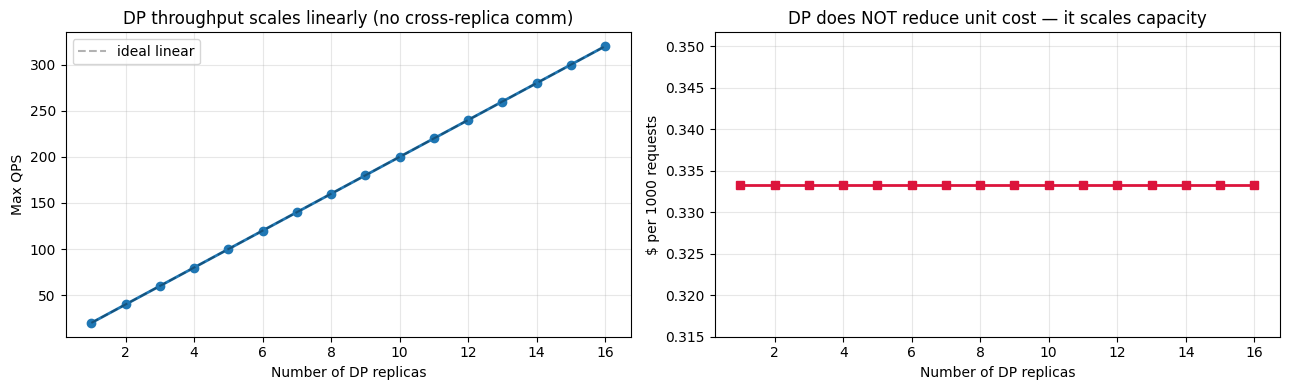


DP cost/throughput table (8xH200 per replica, 20 QPS each):
  Replicas    Total QPS    VRAM (GB)    Cost $/hr   $ / 1k req
--------------------------------------------------------------
         1           20         1128           24       0.3333
         2           40         2256           48       0.3333
         4           80         4512           96       0.3333
         8          160         9024          192       0.3333
        16          320        18048          384       0.3333

Takeaway: DP is a capacity dial, not a cost-efficiency dial.
Unit cost per request stays flat — DP multiplies both throughput and $ spent.
To reduce unit cost, you need the Runtime-layer tricks: quantization, speculative
decoding, prefix caching, disaggregation.


In [5]:
# Simulate data parallelism: throughput vs replicas, under a request arrival rate

import numpy as np
import matplotlib.pyplot as plt

def dp_throughput(n_replicas, per_replica_qps=20, request_rate_qps=None):
    capacity = n_replicas * per_replica_qps
    if request_rate_qps is None:
        return capacity, capacity
    served = min(capacity, request_rate_qps)
    utilization = served / capacity
    return served, utilization

# 1) Linear scaling when request rate is unlimited
replicas = np.arange(1, 17)
throughputs = [dp_throughput(n)[0] for n in replicas]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(replicas, throughputs, 'o-', linewidth=2, markersize=6)
ax1.plot(replicas, throughputs, 'k--', alpha=0.3, label='ideal linear')
ax1.set_xlabel('Number of DP replicas')
ax1.set_ylabel('Max QPS')
ax1.set_title('DP throughput scales linearly (no cross-replica comm)')
ax1.grid(True, alpha=0.3)
ax1.legend()

# 2) Cost curve: VRAM and $ per QPS at different replica counts
# Assume each replica = 8xH200 (1128 GB) for a 671B model
vram_per_replica_gb = 1128
cost_per_hour_per_replica = 24  # rough 8xH200 spot $/hr
throughput_per_replica_qps = 20

replicas_range = np.arange(1, 17)
total_vram = replicas_range * vram_per_replica_gb
total_cost_per_hour = replicas_range * cost_per_hour_per_replica
total_qps = replicas_range * throughput_per_replica_qps
dollars_per_1k_requests = (total_cost_per_hour / 3600) * 1000 / total_qps

ax2.plot(replicas_range, dollars_per_1k_requests, 's-', color='crimson', linewidth=2)
ax2.set_xlabel('Number of DP replicas')
ax2.set_ylabel('$ per 1000 requests')
ax2.set_title('DP does NOT reduce unit cost — it scales capacity')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/tmp/dp_scaling.png', dpi=80)
plt.show()

print()
print('DP cost/throughput table (8xH200 per replica, 20 QPS each):')
print(f"{'Replicas':>10} {'Total QPS':>12} {'VRAM (GB)':>12} {'Cost $/hr':>12} {'$ / 1k req':>12}")
print('-' * 62)
for n in [1, 2, 4, 8, 16]:
    tput = n * throughput_per_replica_qps
    vram = n * vram_per_replica_gb
    cost = n * cost_per_hour_per_replica
    unit_cost = (cost / 3600) * 1000 / tput
    print(f'{n:>10} {tput:>12} {vram:>12} {cost:>12} {unit_cost:>12.4f}')

print()
print('Takeaway: DP is a capacity dial, not a cost-efficiency dial.')
print('Unit cost per request stays flat — DP multiplies both throughput and $ spent.')
print('To reduce unit cost, you need the Runtime-layer tricks: quantization, speculative')
print('decoding, prefix caching, disaggregation.')

## Try These Experiments

1. **GPU count for DeepSeek V3:** DeepSeek V3 has 671B parameters. Using FP8 (1 byte/param), plus 80% for KV cache allocation, calculate the minimum number of B200 GPUs (180GB VRAM each) needed. Then calculate for a sequence of 8192 tokens.

2. **TP communication bottleneck:** Calculate the all-reduce communication overhead for TP=8 during decode with batch_size=1, hidden=8192, on InfiniBand (200 GB/s). Compare to NVLink (900 GB/s). At what batch size does the communication overhead become negligible?

3. **Load balancing in EP:** The simulation shows uneven load across GPUs. Implement a load balancing loss: add a term that penalizes variance in expert selection frequency. This is the auxiliary loss used in DeepSeek and other MoE models.

4. **PP bubble break-even:** Using the `pipeline_bubble` formula, find the minimum number of micro-batches needed to keep the bubble under 10% for PP=4, PP=8, PP=16. Then argue when PP makes sense for *inference* (hint: concurrency, model size relative to a single node).

5. **Picking a parallelism mix:** You must serve Llama 3 405B (810 GB FP16) at 1000 QPS on 8xH200 nodes (1128 GB each). How many nodes total? What TP/PP/DP combination would you pick, and why? There isn't one right answer — justify the tradeoffs.

## Key Takeaways

- **Tensor Parallelism** splits weights within each layer. Low latency, but all-reduce per layer needs NVLink — rarely scales past 8 GPUs.
- **Expert Parallelism** assigns whole experts to GPUs. Less communication than TP, scales to hundreds of GPUs, the reason DeepSeek-V3 and similar MoEs serve efficiently.
- **Pipeline Parallelism** splits layer blocks across stages. Cheap per-stage communication (activations only), so it works across InfiniBand — but the pipeline bubble demands many concurrent micro-batches to amortize.
- **Data Parallelism** replicates the whole model. Zero cross-replica communication, linear throughput, but multiplies VRAM and $ cost. Outer loop around TP/EP/PP.
- Real deployments stack them: `DP[replicas] × (TP[node] × EP[moe] × PP[multi-node])`. TP+PP+EP fit the model and hit a latency budget; DP scales QPS on top.
- The book (Ch 5.4) focuses on TP and EP since those are the *inference-specific* axes. PP borrows from training, DP is trivial replication — but you need all four in your head to reason about a real production deployment.
- **What's next:** Day 18 — prefill/decode disaggregation.

## References
- *Inference Engineering* Ch 5.4 — Model Parallelism (Philip Kiely, Baseten Books, 2026)
- Narayanan et al., *Efficient Large-Scale Language Model Training on GPU Clusters Using Megatron-LM* (2021) — origin of the interleaved pipeline schedule
- Shoeybi et al., *Megatron-LM: Training Multi-Billion Parameter Language Models Using Model Parallelism* (2019) — TP formulation